In [1]:
import cv2
from ultralytics import YOLO

from patched_yolo_infer import (
    MakeCropsDetectThem,
    CombineDetections,
    visualize_results_usual_yolo_inference,
    visualize_results,
)

In [4]:
# Load the image
img_path = '../first_frame_moving.png'
img = cv2.imread(img_path)

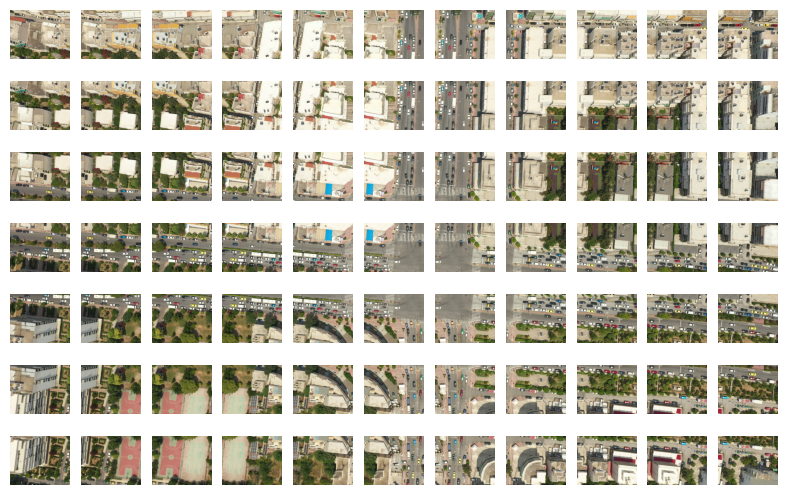

Number of generated images: 77
Basic yolo inference:


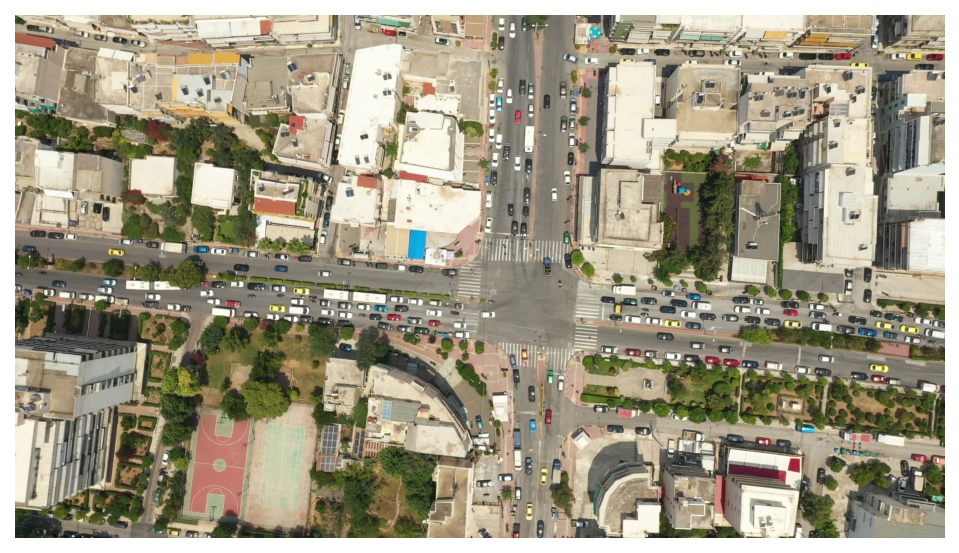

YOLO-Patch-Based-Inference:


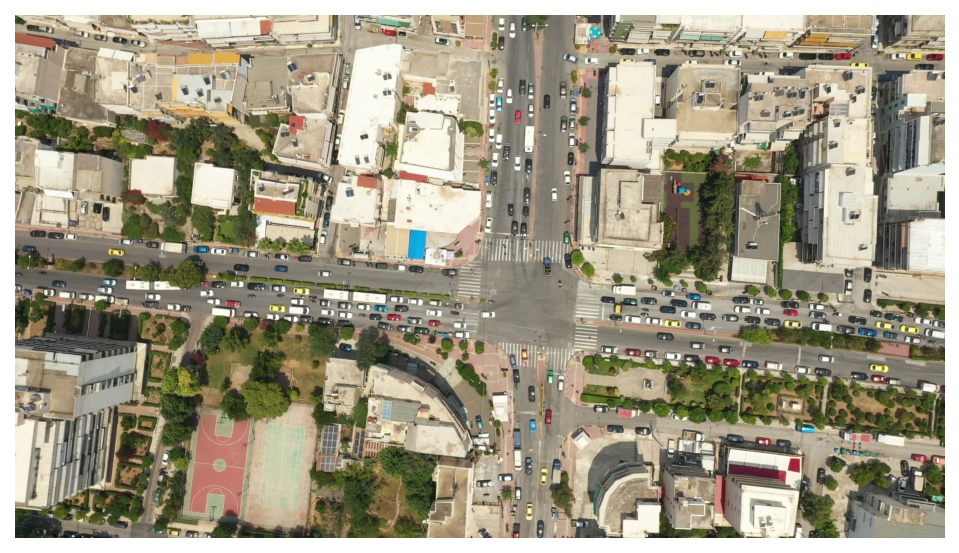

In [8]:
element_crops = MakeCropsDetectThem(
    image=img,
    model_path="yolo11x.pt",
    segment=False,
    show_crops=True,
    shape_x=600,
    shape_y=500,
    overlap_x=50,
    overlap_y=50,
    conf=0.5,
    iou=0.7,
    classes_list=[0, 1, 2, 3, 5, 7, 8, 9, 10],
)
result = CombineDetections(element_crops, nms_threshold=0.05)

print('Basic yolo inference:')
visualize_results_usual_yolo_inference(
    img,
    model=YOLO("yolo11x.pt") ,
    imgsz=640,
    conf=0.5,
    iou=0.7,
    segment=False,
    thickness=8,
    show_boxes=True,
    show_class=False,
)

print('YOLO-Patch-Based-Inference:')
visualize_results(
    img=result.image,
    confidences=result.filtered_confidences,
    boxes=result.filtered_boxes,
    classes_ids=result.filtered_classes_id,
    classes_names=result.filtered_classes_names,
    segment=False,
    thickness=8,
    show_boxes=True,
    show_class=False,
)